In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregamento das imagens em nível de cinza (apenas 1 canal)
img = cv2.imread('gato.jpg', cv2.IMREAD_GRAYSCALE)
img_ref = cv2.imread('gato2.jpg', cv2.IMREAD_GRAYSCALE)

print(f"Dimensões da imagem de entrada (gato.jpg): {img.shape}")
print(f"Dimensões da imagem de referência (gato2.jpg): {img_ref.shape}")


Dimensões da imagem de entrada (gato.jpg): (683, 1024)
Dimensões da imagem de referência (gato2.jpg): (251, 201)


In [ ]:
# FUNÇÕES DE MANIPULAÇÃO DE HISTOGRAMA (IMPLEMENTAÇÃO MANUAL)

def calcular_histograma(imagem):
    """
    Calcula o histograma de uma imagem em nível de cinza manualmente.
    Fórmula: n_k = contagem de pixels com intensidade r_k (para k = 0, ..., L-1, onde L = 256).
    """
    L = 256
    hist = np.zeros(L, dtype=int)
    for pixel in imagem.ravel():
        hist[pixel] += 1
    return hist

def normalizar_histograma(hist, M, N):
    """
    Calcula o histograma normalizado dividindo a quantidade absoluta n_k pelo total de pixels M * N.
    Fórmula: p_r(r_k) = n_k / (M * N).
    """
    total_pixels = M * N
    return hist / total_pixels

def equalizar_histograma(imagem):
    """
    Aplica a equalização de histograma segundo a fórmula discreta da distribuição acumulada:
    s_k = round((L - 1) * sum_{j=0}^k p_r(r_j)), para k = 0, ..., L-1.
    Substitui cada pixel original r_k pelo seu respectivo novo valor s_k.
    """
    M, N = imagem.shape
    L = 256
    
    # 1) Calcula o histograma absoluto e o histograma normalizado
    hist = calcular_histograma(imagem)
    p_r = normalizar_histograma(hist, M, N)
    
    # 2) Aplica a fórmula discreta de equalização acumulada
    s = np.zeros(L, dtype=np.uint8)
    soma_acumulada = 0.0
    for k in range(L):
        soma_acumulada += p_r[k]
        s[k] = int(np.round((L - 1) * soma_acumulada))
        
    # 3) Mapeia cada pixel da imagem de entrada para a nova intensidade s_k
    img_equalizada = np.zeros_like(imagem)
    for r in range(M):
        for c in range(N):
            img_equalizada[r, c] = s[imagem[r, c]]
            
    return img_equalizada, p_r, s

def especificar_histograma(imagem_entrada, imagem_referencia):
    """
    Aplica a especificação do histograma da imagem de entrada para corresponder
    ao histograma da imagem de referência:
    1) Equaliza a imagem de entrada: s_k = round((L - 1) * sum_{j=0}^k p_r(r_j))
    2) Equaliza a imagem de referência: G(z_q) = round((L - 1) * sum_{j=0}^q p_z(z_j))
    3) Mapeia cada s_k para o z_q mais próximo: map[r_k] = argmin_{z_q} |s_k - G(z_q)|
    4) Substitui os pixels da imagem de entrada pelo valor mapeado.
    """
    L = 256
    M_in, N_in = imagem_entrada.shape
    M_ref, N_ref = imagem_referencia.shape
    
    # 1) Equalização do histograma da imagem de entrada
    hist_in = calcular_histograma(imagem_entrada)
    p_in = normalizar_histograma(hist_in, M_in, N_in)
    s_k = np.zeros(L)
    soma_acum_in = 0.0
    for k in range(L):
        soma_acum_in += p_in[k]
        s_k[k] = np.round((L - 1) * soma_acum_in)
        
    # 2) Equalização do histograma da imagem de referência
    hist_ref = calcular_histograma(imagem_referencia)
    p_ref = normalizar_histograma(hist_ref, M_ref, N_ref)
    G_zq = np.zeros(L)
    soma_acum_ref = 0.0
    for q in range(L):
        soma_acum_ref += p_ref[q]
        G_zq[q] = np.round((L - 1) * soma_acum_ref)
        
    # 3) Tabela de mapeamento pela menor distância absoluta entre s_k e G(z_q)
    tabela_mapeamento = np.zeros(L, dtype=np.uint8)
    for k in range(L):
        sk_val = s_k[k]
        diferencas = np.abs(G_zq - sk_val)
        melhor_zq = np.argmin(diferencas)
        tabela_mapeamento[k] = melhor_zq
        
    # 4) Substituição dos pixels da imagem de entrada
    img_especificada = np.zeros_like(imagem_entrada)
    for r in range(M_in):
        for c in range(N_in):
            img_especificada[r, c] = tabela_mapeamento[imagem_entrada[r, c]]
            
    return img_especificada


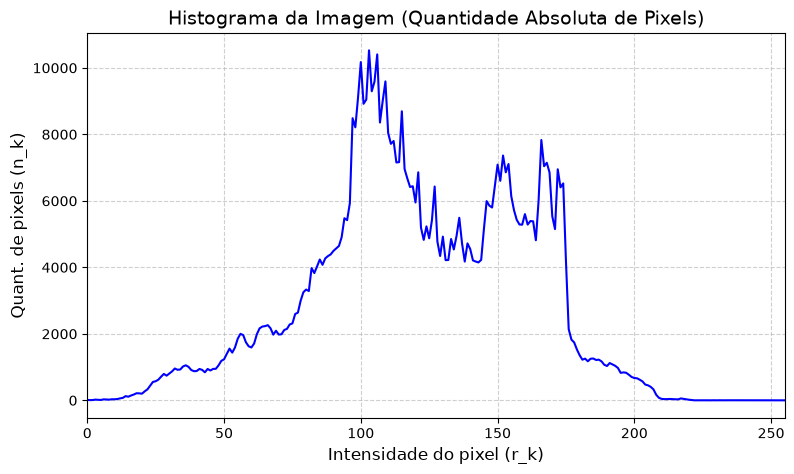

In [ ]:
# 1) a) Calcule o histograma utilizando a fórmula correspondente e apresente o gráfico resultante.

M, N = img.shape
hist_original = calcular_histograma(img)

plt.figure(figsize=(9, 5))
plt.plot(range(256), hist_original, color='blue', linewidth=1.5)
plt.title('Histograma da Imagem', fontsize=14)
plt.xlabel('Intensidade do pixel (r_k)', fontsize=12)
plt.ylabel('Quant. de pixels (n_k)', fontsize=12)
plt.xlim([0, 255])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


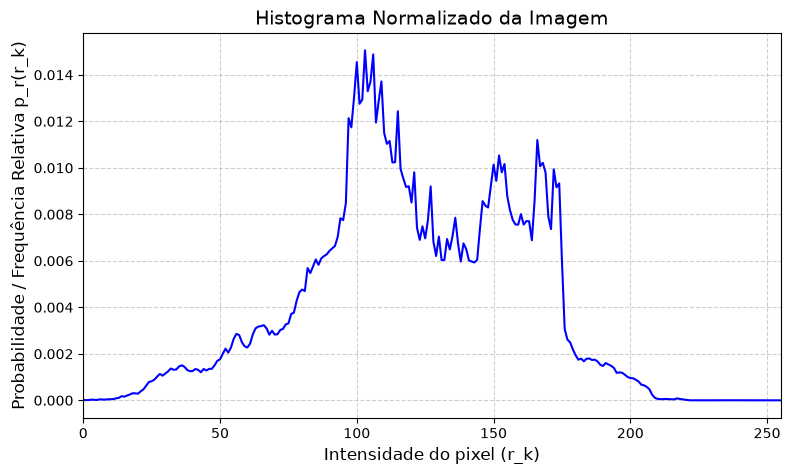

In [ ]:
# 1) b) Normalize o histograma utilizando a fórmula correspondente e apresente o gráfico resultante.

hist_norm_original = normalizar_histograma(hist_original, M, N)

plt.figure(figsize=(9, 5))
plt.plot(range(256), hist_norm_original, color='blue', linewidth=1.5)
plt.title('Histograma Normalizado da Imagem', fontsize=14)
plt.xlabel('Intensidade do pixel (r_k)', fontsize=12)
plt.ylabel('Probabilidade / Frequência Relativa p_r(r_k)', fontsize=12)
plt.xlim([0, 255])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


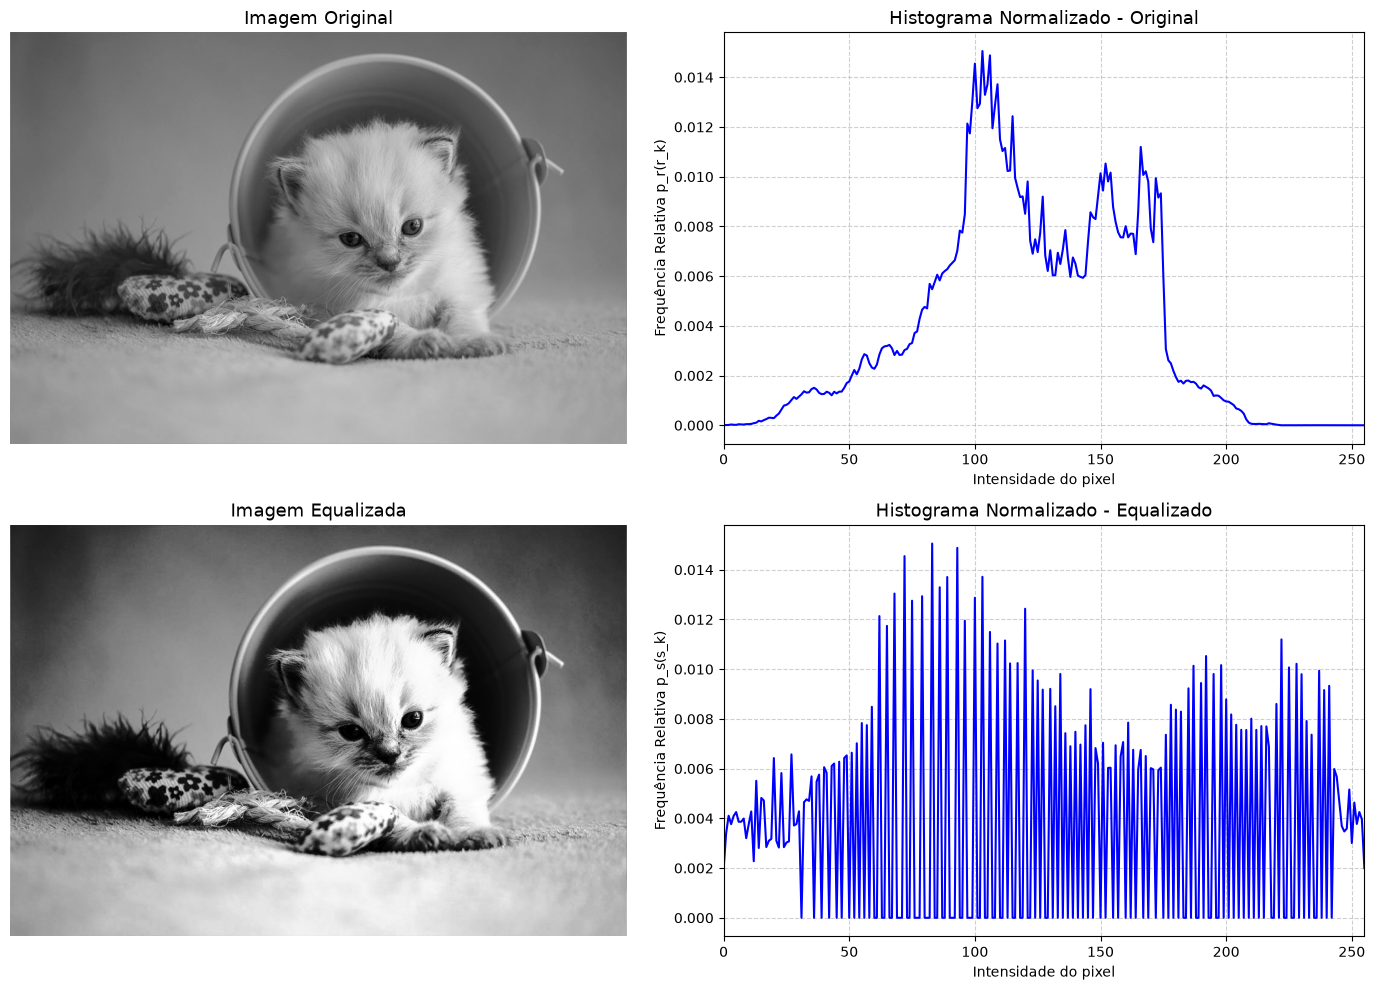

In [ ]:
# 1) c) Aplique a equalização do histograma utilizando a fórmula.
# Mostre a imagem original juntamente com o gráfico do seu histograma normalizado.
# Adicionalmente, mostre a imagem após a equalização e seu histograma correspondente.

img_equalizada, _, _ = equalizar_histograma(img)
M_eq, N_eq = img_equalizada.shape
hist_eq = calcular_histograma(img_equalizada)
hist_norm_eq = normalizar_histograma(hist_eq, M_eq, N_eq)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Imagem original e seu histograma normalizado
axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set_title('Imagem Original', fontsize=13)
axs[0, 0].axis('off')

axs[0, 1].plot(range(256), hist_norm_original, color='blue', linewidth=1.5)
axs[0, 1].set_title('Histograma Normalizado - Original', fontsize=13)
axs[0, 1].set_xlabel('Intensidade do pixel')
axs[0, 1].set_ylabel('Frequência Relativa p_r(r_k)')
axs[0, 1].set_xlim([0, 255])
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# Imagem equalizada e seu histograma normalizado
axs[1, 0].imshow(img_equalizada, cmap='gray')
axs[1, 0].set_title('Imagem Equalizada', fontsize=13)
axs[1, 0].axis('off')

axs[1, 1].plot(range(256), hist_norm_eq, color='blue', linewidth=1.5)
axs[1, 1].set_title('Histograma Normalizado - Equalizado', fontsize=13)
axs[1, 1].set_xlabel('Intensidade do pixel')
axs[1, 1].set_ylabel('Frequência Relativa p_s(s_k)')
axs[1, 1].set_xlim([0, 255])
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


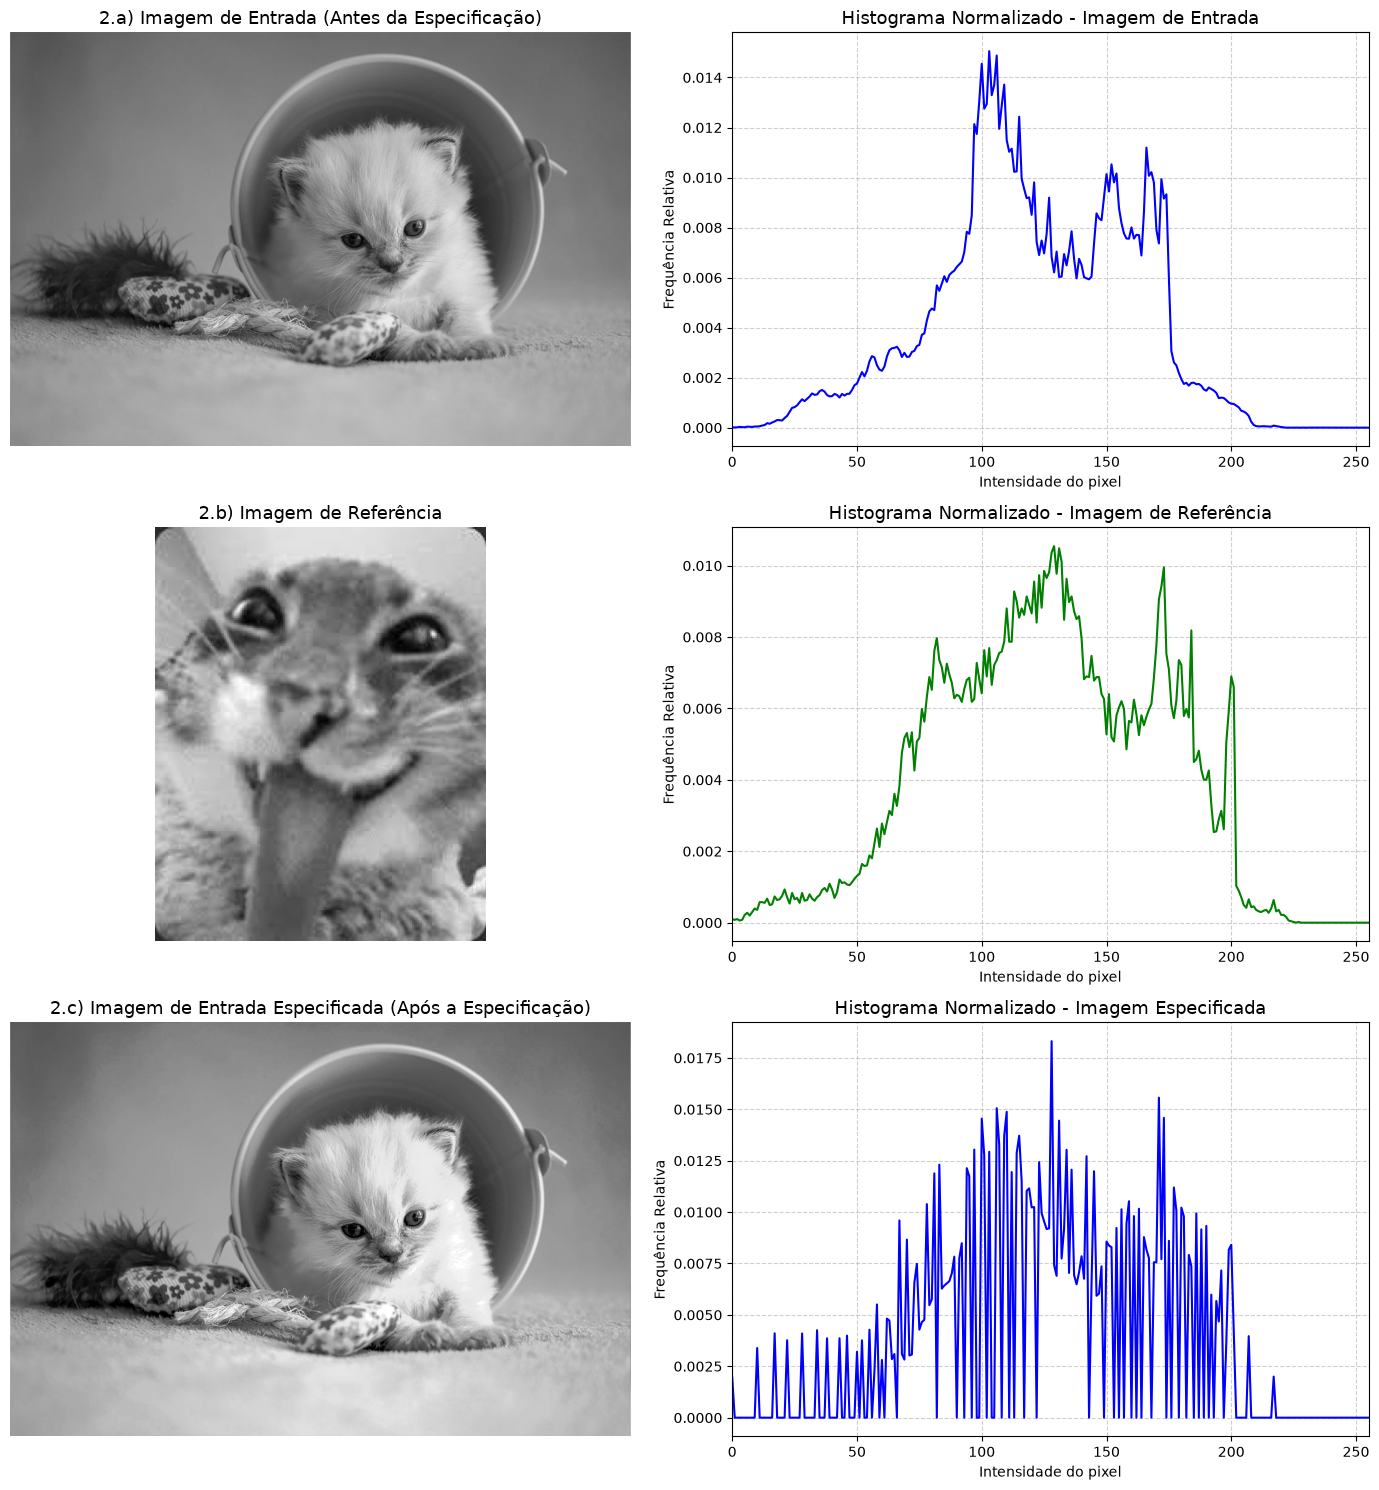

In [ ]:
# 2) Aplique a especificação do histograma utilizando a fórmula e mostre os seguintes itens:
# a) Mostre a imagem de entrada, juntamente com o gráfico do seu histograma normalizado antes da especificação.
# b) Mostre a imagem de referência, juntamente com o gráfico do seu histograma normalizado.
# c) Mostre a imagem de entrada, juntamente com o gráfico do seu histograma normalizado após a especificação.

img_especificada = especificar_histograma(img, img_ref)

M_ref, N_ref = img_ref.shape
hist_ref = calcular_histograma(img_ref)
hist_norm_ref = normalizar_histograma(hist_ref, M_ref, N_ref)

M_esp, N_esp = img_especificada.shape
hist_esp = calcular_histograma(img_especificada)
hist_norm_esp = normalizar_histograma(hist_esp, M_esp, N_esp)

fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# a) Imagem de entrada antes da especificação e seu histograma normalizado
axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set_title('2.a) Imagem de Entrada (Antes da Especificação)', fontsize=13)
axs[0, 0].axis('off')

axs[0, 1].plot(range(256), hist_norm_original, color='blue', linewidth=1.5)
axs[0, 1].set_title('Histograma Normalizado - Imagem de Entrada', fontsize=13)
axs[0, 1].set_xlabel('Intensidade do pixel')
axs[0, 1].set_ylabel('Frequência Relativa')
axs[0, 1].set_xlim([0, 255])
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# b) Imagem de referência e seu histograma normalizado
axs[1, 0].imshow(img_ref, cmap='gray')
axs[1, 0].set_title('2.b) Imagem de Referência', fontsize=13)
axs[1, 0].axis('off')

axs[1, 1].plot(range(256), hist_norm_ref, color='green', linewidth=1.5)
axs[1, 1].set_title('Histograma Normalizado - Imagem de Referência', fontsize=13)
axs[1, 1].set_xlabel('Intensidade do pixel')
axs[1, 1].set_ylabel('Frequência Relativa')
axs[1, 1].set_xlim([0, 255])
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# c) Imagem de entrada após a especificação e seu histograma normalizado
axs[2, 0].imshow(img_especificada, cmap='gray')
axs[2, 0].set_title('2.c) Imagem de Entrada Especificada (Após a Especificação)', fontsize=13)
axs[2, 0].axis('off')

axs[2, 1].plot(range(256), hist_norm_esp, color='blue', linewidth=1.5)
axs[2, 1].set_title('Histograma Normalizado - Imagem Especificada', fontsize=13)
axs[2, 1].set_xlabel('Intensidade do pixel')
axs[2, 1].set_ylabel('Frequência Relativa')
axs[2, 1].set_xlim([0, 255])
axs[2, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
